# Generative Adversarial Network (GAN) - PyTorch


Using device: cuda

Generator:
 Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)

Discriminator:
 Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): Leaky

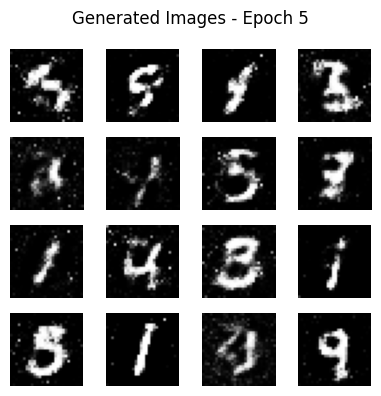

Epoch [6/20] | D Loss: 0.5994 | G Loss: 1.2069
Epoch [7/20] | D Loss: 0.6067 | G Loss: 1.1831
Epoch [8/20] | D Loss: 0.6086 | G Loss: 1.1729
Epoch [9/20] | D Loss: 0.6147 | G Loss: 1.1486
Epoch [10/20] | D Loss: 0.6164 | G Loss: 1.1371


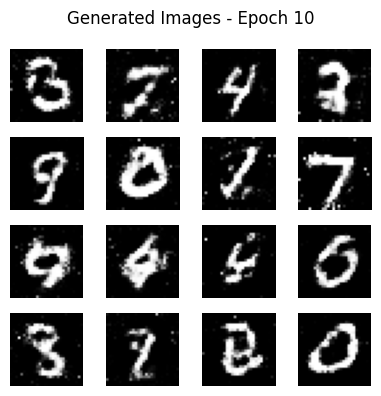

Epoch [11/20] | D Loss: 0.6199 | G Loss: 1.1295
Epoch [12/20] | D Loss: 0.6234 | G Loss: 1.1076
Epoch [13/20] | D Loss: 0.6261 | G Loss: 1.0964
Epoch [14/20] | D Loss: 0.6292 | G Loss: 1.0863
Epoch [15/20] | D Loss: 0.6294 | G Loss: 1.0876


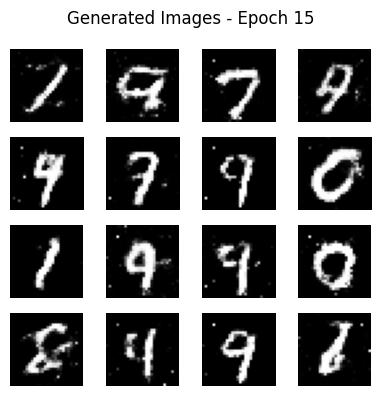

Epoch [16/20] | D Loss: 0.6319 | G Loss: 1.0685
Epoch [17/20] | D Loss: 0.6347 | G Loss: 1.0580
Epoch [18/20] | D Loss: 0.6344 | G Loss: 1.0581
Epoch [19/20] | D Loss: 0.6374 | G Loss: 1.0459
Epoch [20/20] | D Loss: 0.6371 | G Loss: 1.0436


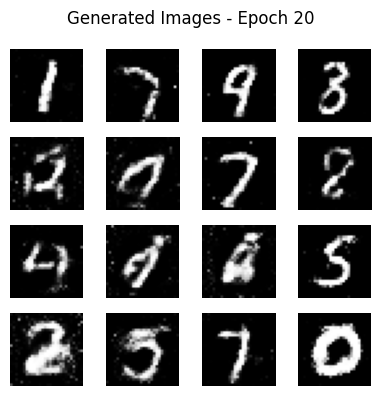


GAN models saved successfully!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =========================================================
# 1. Device Configuration
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================================================
# 2. Hyperparameters
# =========================================================
BATCH_SIZE = 128
EPOCHS = 20
NOISE_DIM = 100
IMAGE_DIM = 784
LEARNING_RATE = 0.0002

# =========================================================
# 3. Load MNIST Dataset
# =========================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1]
])

train_dataset = datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)

# =========================================================
# 4. Build Generator
# =========================================================
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(NOISE_DIM, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, IMAGE_DIM),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# =========================================================
# 5. Build Discriminator
# =========================================================
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(IMAGE_DIM, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

# =========================================================
# 6. Initialize Models
# =========================================================
generator = Generator().to(device)
discriminator = Discriminator().to(device)

print("\nGenerator:\n", generator)
print("\nDiscriminator:\n", discriminator)

# =========================================================
# 7. Loss & Optimizers
# =========================================================
adversarial_loss = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

# =========================================================
# 8. Training Loop
# =========================================================
for epoch in range(EPOCHS):

    # Ensure models are in training mode
    generator.train()
    discriminator.train()

    g_losses, d_losses = [], []

    for i, (imgs, _) in enumerate(train_loader):
        batch_size = imgs.size(0)

        # =============================================
        # Prepare Real and Fake Labels
        # =============================================
        # Label smoothing: 0.9 instead of 1.0 for real images
        real_labels = (torch.ones(batch_size, 1) * 0.9).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # =============================================
        # Prepare Real Images
        # =============================================
        real_images = imgs.view(batch_size, -1).to(device)

        # =============================================
        # Train Discriminator
        # =============================================
        optimizer_D.zero_grad()

        # Real image loss
        real_pred = discriminator(real_images)
        real_loss = adversarial_loss(real_pred, real_labels)

        # Fake image loss
        z = torch.randn(batch_size, NOISE_DIM).to(device)
        fake_images = generator(z)

        # Detach fake_images so gradients don't flow back to generator here
        fake_pred = discriminator(fake_images.detach())
        fake_loss = adversarial_loss(fake_pred, fake_labels)

        # Total discriminator loss
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # =============================================
        # Train Generator
        # =============================================
        optimizer_G.zero_grad()

        # We want to trick the discriminator into outputting 1.0
        trick_labels = torch.ones(batch_size, 1).to(device)

        # Generator tries to fool discriminator (using updated D)
        validity = discriminator(fake_images)
        g_loss = adversarial_loss(validity, trick_labels)

        # Backpropagation
        g_loss.backward()
        optimizer_G.step()

        # Save losses
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

    # =====================================================
    # Epoch Results
    # =====================================================
    avg_g_loss = sum(g_losses) / len(g_losses)
    avg_d_loss = sum(d_losses) / len(d_losses)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}")

    # =====================================================
    # Generate Sample Images Every 5 Epochs
    # =====================================================
    if (epoch + 1) % 5 == 0:
        generator.eval() # Set to evaluation mode for BatchNorm

        with torch.no_grad():
            z = torch.randn(16, NOISE_DIM).to(device)
            generated = generator(z).view(-1, 28, 28).cpu()

            # Rescale from [-1,1] -> [0,1]
            generated = (generated + 1) / 2

            plt.figure(figsize=(4, 4))
            for j in range(16):
                plt.subplot(4, 4, j + 1)
                plt.imshow(generated[j], cmap="gray")
                plt.axis("off")

            plt.suptitle(f"Generated Images - Epoch {epoch+1}")
            plt.tight_layout()
            plt.show()

# =========================================================
# 9. Save Models
# =========================================================
torch.save(generator.state_dict(), "generator.pth")
torch.save(discriminator.state_dict(), "discriminator.pth")

print("\nGAN models saved successfully!")